In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

A nova versão da experiência do usuário (V1) aumenta significativamente a taxa de conversão em comparação com a versão atual (Controle)?

In [3]:

path = r"C:\Users\Brener\.cache\kagglehub\datasets\surajatiitb\ecommerce-conversion-ab-test-data\versions\1\ecommerce_conversion_ab_test_data.csv"

df = pd.read_csv(path)

df.sample(15)

,TvC,date,traffic_source,device_type,browser_language,login_y_n,region,return_y_n,conversion
1896213,V1,2021-02-01,Organic,Desktop,English,y,West,n,0
460649,C,2021-02-05,Direct,Mweb,English,n,West,n,0
1444132,V1,2021-02-13,Organic,Iphone,English,n,Northeast,y,0
587335,C,2021-02-01,Direct,Mweb,English,n,Southwest,y,0
1952137,V1,2021-02-11,Referrals,Android,English,n,Southeast,y,0
1207391,V1,2021-02-08,Organic,Mweb,Spanish,n,West,y,0
1929712,V1,2021-02-09,Social Media,Mweb,Spanish,n,Southwest,n,0
1176356,V1,2021-02-01,Direct,Iphone,English,n,West,y,0
1766913,V1,2021-02-13,Organic,Desktop,English,n,West,y,1
47219,C,2021-02-12,Organic,Mweb,English,n,West,n,0


In [4]:
df.shape

(2000000, 9)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000000 entries, 0 to 1999999
Data columns (total 9 columns):
 #   Column            Dtype 
---  ------            ----- 
 0   TvC               object
 1   date              object
 2   traffic_source    object
 3   device_type       object
 4   browser_language  object
 5   login_y_n         object
 6   region            object
 7   return_y_n        object
 8   conversion        int64 
dtypes: int64(1), object(8)
memory usage: 137.3+ MB


# EDA

In [6]:
print(f"Nulos \n{df.isnull().sum()}")
print(f"\nDuplicados {df.duplicated().sum()}")

Nulos 
TvC                 0
date                0
traffic_source      0
device_type         0
browser_language    0
login_y_n           0
region              0
return_y_n          0
conversion          0
dtype: int64

Duplicados 1895422


In [7]:
df.head()

,TvC,date,traffic_source,device_type,browser_language,login_y_n,region,return_y_n,conversion
0,C,2021-02-14,Referrals,Mweb,Chinese,n,Southwest,y,1
1,C,2021-02-14,Direct,Iphone,English,y,West,y,0
2,C,2021-02-11,Email Marketing,Mweb,English,y,Northeast,y,0
3,C,2021-02-11,Referrals,Iphone,English,y,Southwest,n,0
4,C,2021-02-01,Referrals,Desktop,English,y,Northeast,n,0


In [8]:
df[df.duplicated()].head()

,TvC,date,traffic_source,device_type,browser_language,login_y_n,region,return_y_n,conversion
160,C,2021-02-12,Organic,Mweb,English,n,West,y,0
243,C,2021-02-08,Organic,Mweb,English,y,West,y,0
329,C,2021-02-15,Organic,Mweb,English,n,West,y,0
332,C,2021-02-13,Organic,Mweb,English,n,West,y,0
357,C,2021-02-05,Referrals,Mweb,English,n,West,n,0


In [9]:
duplicados = df.duplicated().sum()

percentual = duplicados / len(df) * 100

print(percentual)

94.77109999999999


Durante a etapa de validação dos dados foi identificado que aproximadamente 94,8% das linhas possuíam combinações repetidas das variáveis disponíveis. No entanto segundo a descrição do Kaggle cada linha representa um usuário único sendo assim manteremos os dados 

In [10]:
# Distribuição dos Dados(Controle e Tratamento)
print(df['TvC'].value_counts())

TvC
C     1000000
V1    1000000
Name: count, dtype: int64


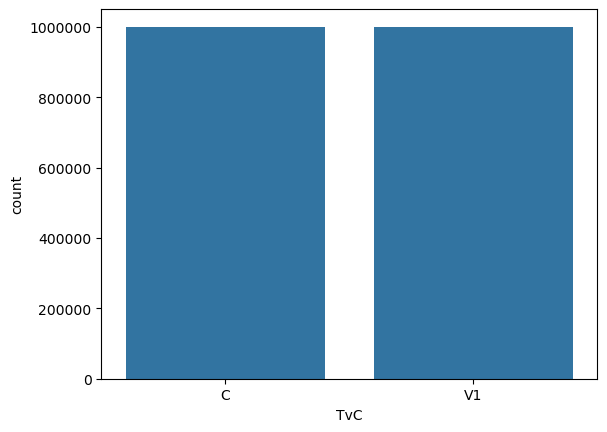

In [11]:
tips = sns.load_dataset("tips")
sns.countplot(data=df, x='TvC')
plt.ticklabel_format(style='plain', axis='y')
plt.show()

In [12]:
# Distribuição no grupos
print(pd.crosstab(df['TvC'],df['conversion']))

conversion       0       1
TvC                       
C           899908  100092
V1          890116  109884


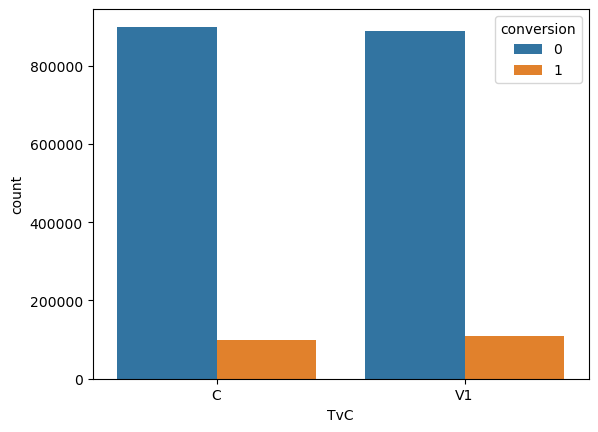

In [13]:
# Visualização Grafica da Conversão nos grupos
sns.countplot(data= df, x ='TvC', hue= 'conversion')
plt.show()

In [14]:
# Taxa Conversão para Grupo

taxa_coversao = df.groupby('TvC')['conversion'].mean()
taxa_coversao

TvC
C     0.100092
V1    0.109884
Name: conversion, dtype: float64

# Teste A/B - Teste do Qui-Quadrado

O teste Qui-Quadrado foi escolhido por avaliar a associação entre duas variáveis categóricas: grupo experimental (Controle/V1) e conversão (0/1).

In [15]:
tabela_contigencia = pd.crosstab(df['TvC'],df['conversion'])
tabela_contigencia

conversion,0,1
TvC,,
C,899908,100092
V1,890116,109884


In [16]:
from scipy.stats import chi2_contingency

chip2,p_value,_,_=chi2_contingency(tabela_contigencia)

print(f"Estatistica {chip2}")
print(f"Valor-p : {p_value}")

hipotese_nula = "Não há associação ou diferença significativa."
hipotese_alternativa = "Existe associação ou diferença significativa."
alpha = 0.05

if p_value < alpha:
    print(f"\nRejeitamos H0 → {hipotese_alternativa}")
else:
    print(f"\nFalhamos em rejeitar H0 → {hipotese_nula}")



Estatistica 510.10030672372636
Valor-p : 6.031020407491675e-113

Rejeitamos H0 → Existe associação ou diferença significativa.


Dado que o p-valor encontrado (p ≈ 6,03 × 10⁻¹¹³) é substancialmente inferior ao nível de significância convencional de 5%, rejeita-se a hipótese nula de igualdade entre as taxas de conversão. Conclui-se, portanto, que há evidência estatística robusta para aceitar a hipótese alternativa, indicando diferença significativa entre os grupos analisados.

# Analisando o Teste t de Student para validação do Teste do Qui-Quadrado

In [17]:
import scipy.stats as stats
from scipy.stats import ttest_ind

# Separando dados

grupo_controle = df[df['TvC'] == 'C']
grupo_tratamento = df[df['TvC'] == 'V1']

# Aplicando o teste

estatistica_t,p_value = stats.ttest_ind(grupo_controle['conversion'],grupo_tratamento['conversion'])

print(f"Estatistica {estatistica_t}")
print(f"Valor-p : {p_value}")

if p_value < alpha:
    print(f"\nRejeitamos H0 → {hipotese_alternativa}")
else:
    print(f"\nFalhamos em rejeitar H0 → {hipotese_nula}")

Estatistica -22.59057739495515
Valor-p : 5.54238446529156e-113

Rejeitamos H0 → Existe associação ou diferença significativa.


Os resultados do teste t de Student para duas amostras independentes (t = -22,59; p < 0,001) corroboram os achados do teste qui-quadrado, indicando diferença estatisticamente significativa entre os grupos analisados. A convergência dos métodos paramétrico e não paramétrico fortalece a evidência empírica, sustentando a rejeição da hipótese nula e a aceitação da hipótese alternativa de que as taxas de conversão diferem entre os grupos

# Suposições de validação dos Testes:

No presente estudo, não é possível garantir empiricamente todas as suposições necessárias para a aplicação dos testes estatísticos, uma vez que os dados não foram coletados diretamente pelo pesquisador. Contudo, considerando que o dataset possui usuários únicos e que os grupos analisados são independentes, assume-se como verdadeiras as condições de independência das observações e das amostras. Essa pressuposição é necessária para a continuidade da análise e interpretação dos resultados.

## Avaliação Complementar da Distribuição dos Dados

Embora a variável de conversão seja binária (0 = não converteu, 1 = converteu) e o teste Qui-Quadrado não exija normalidade, foram realizadas análises complementares de distribuição para compreender melhor o comportamento dos dados e comparar diferentes abordagens estatísticas.

Essas análises têm caráter exploratório e não constituem um pressuposto necessário para a aplicação do teste Qui-Quadrado.

In [18]:
# Validando Shapiro-Wilk

from scipy.stats import shapiro

amostra_A = grupo_controle['conversion'].sample(n=5000, random_state=42)
amostra_B = grupo_tratamento['conversion'].sample(n=5000, random_state=42)

stat_A,p_A = shapiro(amostra_A)
stat_B,p_B = shapiro(amostra_B)

print(f"Controle: W={stat_A:.4f}, p={p_A:.4e}")
print(f"Tratamento: W={stat_B:.4f}, p={p_B:.4e}")

Controle: W=0.3476, p=5.2443e-86
Tratamento: W=0.3633, p=1.8411e-85


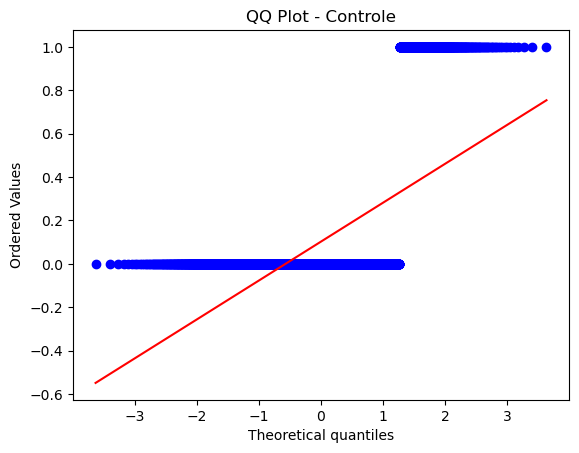

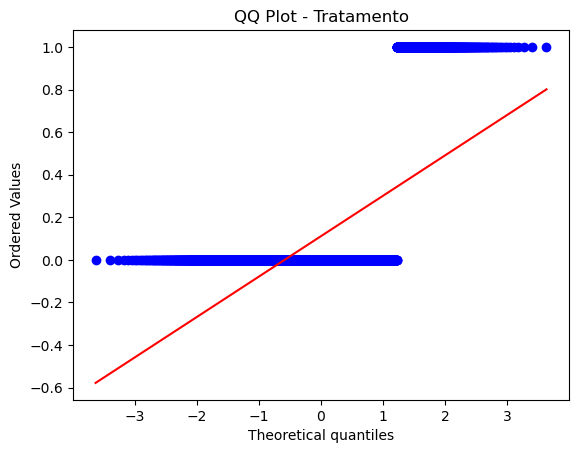

In [19]:
import scipy.stats as stats
import matplotlib.pyplot as plt

stats.probplot(amostra_A, dist="norm", plot=plt)
plt.title("QQ Plot - Controle")
plt.show()

stats.probplot(amostra_B, dist="norm", plot=plt)
plt.title("QQ Plot - Tratamento")
plt.show()

A análise gráfica por meio de histogramas reforça os resultados obtidos pelo teste de Shapiro-Wilk e pelos QQ-plots, evidenciando que os dados não seguem uma distribuição normal. Essa constatação é esperada, dado que a variável de conversão é binária (0/1). Apesar disso, em amostras muito grandes, o Teorema Central do Limite garante que a distribuição da média tende à normalidade, o que torna o teste t de Student suficientemente robusto para a comparação entre grupos

In [20]:
# Teste de Levene - homogeneidade de variâncias

controle = grupo_controle['conversion']
tratamento = grupo_tratamento['conversion']

stat_levene, p_levene = stats.levene(controle, tratamento)

print("Estatística de Levene:", stat_levene)
print("p-valor:", p_levene)

Estatística de Levene: 510.33418703745855
p-valor: 5.542384465291877e-113


O teste de Levene indicou rejeição da hipótese nula de homogeneidade de variâncias (estatística = 510,33; p < 0,001). Portanto, não podemos assumir variâncias iguais entre os grupos. Diante desse resultado, a aplicação do teste t de Student clássico não é adequada. Para contornar essa limitação, utilizamos o teste t de Welch, que não exige homogeneidade de variâncias e é mais robusto em cenários de variâncias distintas.

In [21]:
# Teste t de Welch (equal_var=False)

controle = grupo_controle['conversion'].values
tratamento = grupo_tratamento['conversion'].values


estatistica_t, p_value = stats.ttest_ind(controle, tratamento, equal_var=False)

print("Estatística t (Welch):", estatistica_t)
print("p-valor:", p_value)

Estatística t (Welch): -22.590577394955147
p-valor: 5.542691456345963e-113


O teste de Welch foi aplicado devido à rejeição da hipótese de homogeneidade de variâncias pelo teste de Levene. Os resultados (t = -22,59; p < 0,001) confirmam a existência de diferença estatisticamente significativa entre os grupos controle e tratamento. Esse achado reforça os resultados obtidos pelo teste qui-quadrado, indicando que a intervenção aplicada ao grupo tratamento impactou de forma significativa a taxa de conversão. Apesar da não-normalidade dos dados brutos (variável binária), o tamanho da amostra e a robustez do Teorema Central do Limite sustentam a validade do teste paramétrico utilizado. Assim, a convergência dos diferentes métodos estatísticos fortalece a evidência empírica e permite rejeitar a hipótese nula com elevado grau de confiança.

# Regressão Logistica

In [22]:
from sklearn.linear_model import LogisticRegression


df['grupo_num'] = df['TvC'].map({'C':0, 'V1':1})

X = df[['grupo_num']]   
y = df['conversion']    

# Ajustando regressão logística
modelo = LogisticRegression()
modelo.fit(X, y)

# Coeficientes
intercepto = modelo.intercept_[0]
coef_grupo = modelo.coef_[0][0]

print("Intercepto:", intercepto)
print("Coeficiente do grupo (tratamento vs controle):", coef_grupo)
# Odds ratio

odds_ratio = np.exp(coef_grupo)
print("Odds Ratio (tratamento vs controle):", odds_ratio)

# Probabilidades previstas
prob_controle = modelo.predict_proba([[0]])[0][1]
prob_tratamento = modelo.predict_proba([[1]])[0][1]

print("Probabilidade de conversão - Controle:", prob_controle)
print("Probabilidade de conversão - Tratamento:", prob_tratamento)
print("Diferença absoluta:", prob_tratamento - prob_controle)

Intercepto: -2.1973136709319014
Coeficiente do grupo (tratamento vs controle): 0.10529032860622208
Odds Ratio (tratamento vs controle): 1.1110331282349437
Probabilidade de conversão - Controle: 0.0999919818621398
Probabilidade de conversão - Tratamento: 0.10987453093735253
Diferença absoluta: 0.00988254907521273


c:\Users\Brener\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
c:\Users\Brener\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


A regressão logística aplicada aos grupos controle (C) e tratamento (V1) mostrou que o tratamento exerce efeito positivo sobre a probabilidade de conversão. O coeficiente associado ao grupo V1 foi positivo (β = 0,105), com odds ratio de 1,11, indicando que o tratamento aumenta em aproximadamente 11% as chances de conversão em relação ao controle. As probabilidades previstas reforçam esse resultado: 9,99% para o grupo controle e 10,99% para o grupo tratamento, representando uma diferença absoluta de cerca de 1 ponto percentual. Esse modelo complementa os testes de hipóteses realizados (qui-quadrado e t de Welch), fornecendo uma medida clara da magnitude do efeito do tratamento sobre a variável resposta.

A versão V1 apresentou uma taxa de conversão de 10,99%, superior à taxa observada no grupo controle, que foi de 10,01%. Isso representa um ganho absoluto de aproximadamente 0,98 ponto percentual e um aumento relativo de cerca de 9,78% na conversão.

Os testes estatísticos aplicados indicaram que essa diferença é estatisticamente significativa, sugerindo que o aumento observado dificilmente ocorreu por acaso.

Dessa forma, recomenda-se a implementação da versão V1 para toda a base de usuários, com monitoramento contínuo da taxa de conversão por fonte de tráfego, dispositivo e região. Também é importante considerar a limitação do dataset, que não possui identificador único de usuário, impossibilitando confirmar se registros repetidos representam usuários distintos ou duplicações reais.

# O efeito do tratamento foi consistente entre as diferentes Fontes de Tráfego ?

Após identificar um efeito positivo geral da versão V1, investigou-se se esse impacto permanecia consistente entre diferentes fontes de aquisição de usuários.

In [23]:

for source in df['traffic_source'].unique():

    temp = df[df['traffic_source'] == source]

    table = pd.crosstab(
        temp['TvC'],
        temp['conversion']
    )

    chi2, p_value, _, _ = chi2_contingency(table)

    print(f"\nFonte: {source}")
    print(f"Qui²: {chi2:.4f}")
    print(f"P-value: {p_value:.10f}")

    if p_value < 0.05:
        print("Resultado: Significativo")
    else:
        print("Resultado: Não significativo")


Fonte: Referrals
Qui²: 58.9214
P-value: 0.0000000000
Resultado: Significativo

Fonte: Direct
Qui²: 103.9936
P-value: 0.0000000000
Resultado: Significativo

Fonte: Email Marketing
Qui²: 51.6539
P-value: 0.0000000000
Resultado: Significativo

Fonte: Paid Search
Qui²: 61.3211
P-value: 0.0000000000
Resultado: Significativo

Fonte: Organic
Qui²: 190.8536
P-value: 0.0000000000
Resultado: Significativo

Fonte: Social Media
Qui²: 46.2264
P-value: 0.0000000000
Resultado: Significativo


In [24]:
import pandas as pd

resultados = []

for source in df['traffic_source'].unique():

    temp = df[df['traffic_source'] == source]

    taxas = temp.groupby('TvC')['conversion'].mean()

    controle = taxas['C']
    tratamento = taxas['V1']

    lift_abs = tratamento - controle
    lift_rel = (lift_abs / controle) * 100

    resultados.append({
        'Traffic Source': source,
        'Controle Rate (%)': controle * 100,
        'Tratamento Rate (%)': tratamento * 100,
        'Absolute Lift (%)': lift_abs * 100,
        'Relative Lift (%)': lift_rel
    })

lift_df = pd.DataFrame(resultados)

lift_df = lift_df.sort_values(
    by='Relative Lift (%)',
    ascending=False
)

lift_df.reset_index(drop=True, inplace=True)

lift_df

,Traffic Source,Controle Rate (%),Tratamento Rate (%),Absolute Lift (%),Relative Lift (%)
0,Social Media,9.743979,10.852490,1.108511,11.376371
1,Email Marketing,9.969171,11.074608,1.105437,11.088552
2,Paid Search,9.997112,11.072004,1.074891,10.752016
3,Direct,10.028890,11.018848,0.989958,9.871062
4,Organic,9.996848,10.942489,0.945640,9.459386
5,Referrals,10.168331,11.032000,0.863669,8.493714


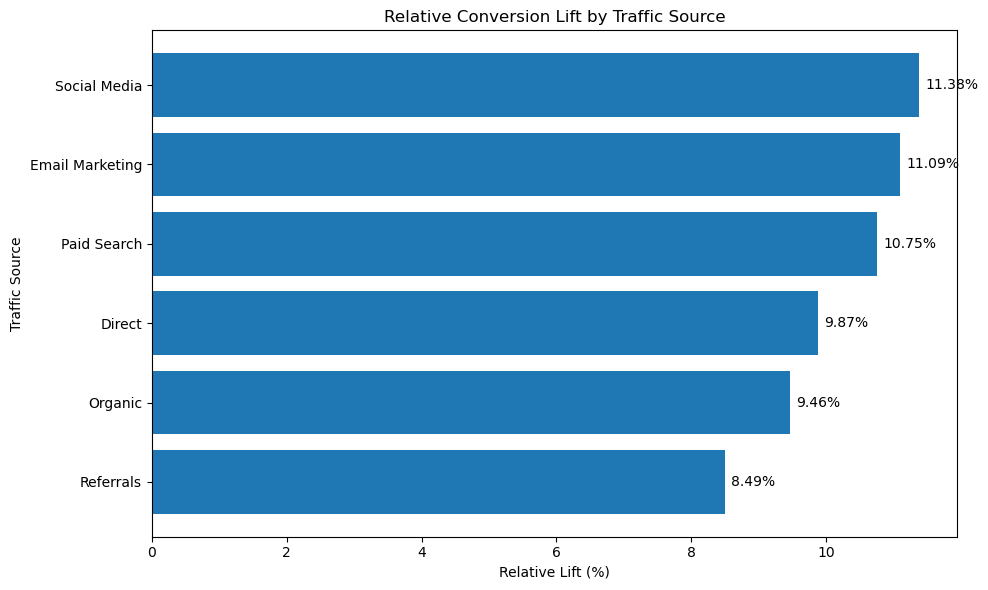

In [26]:
import matplotlib.pyplot as plt

# Ordena do maior para o menor
grafico = lift_df.sort_values(
    by='Relative Lift (%)',
    ascending=True
)

plt.figure(figsize=(10,6))

plt.barh(
    grafico['Traffic Source'],
    grafico['Relative Lift (%)']
)

plt.xlabel('Relative Lift (%)')
plt.ylabel('Traffic Source')
plt.title('Relative Conversion Lift by Traffic Source')

# Valores ao lado das barras
for i, valor in enumerate(grafico['Relative Lift (%)']):
    plt.text(
        valor + 0.1,
        i,
        f'{valor:.2f}%',
        va='center'
    )

plt.tight_layout()



plt.show()

## Análise por Fonte de Tráfego

Com o objetivo de verificar se o impacto da versão V1 era consistente entre diferentes canais de aquisição, foi realizada uma análise segmentada por fonte de tráfego.

Os testes Qui-Quadrado indicaram associação estatisticamente significativa entre a versão exibida e a conversão para todas as fontes analisadas (p-value < 0,05).

Além da significância estatística, foi avaliado o tamanho do efeito por meio do lift relativo da taxa de conversão.

Os resultados mostraram ganhos consistentes em todos os canais:

* Social Media: +11,38%
* Email Marketing: +11,09%
* Paid Search: +10,75%
* Direct: +9,87%
* Organic: +9,46%
* Referrals: +8,49%

Os resultados sugerem que a melhoria introduzida pela versão V1 não está restrita a um único segmento de usuários, mas apresenta impacto positivo de forma ampla e consistente em todas as principais fontes de tráfego analisadas.


## Conclusão e Recomendação de Negócio

A análise identificou que a versão V1 apresentou uma taxa de conversão superior à observada no grupo controle, passando de aproximadamente 10,01% para 10,99%.

Os testes estatísticos realizados forneceram evidências suficientes para rejeitar a hipótese nula, indicando que a diferença observada dificilmente ocorreu por acaso.

A análise segmentada por fonte de tráfego reforçou essa conclusão, demonstrando ganhos consistentes em todos os canais avaliados, com lifts relativos variando entre 8,49% e 11,38%.

Dessa forma, recomenda-se a implementação da versão V1 para toda a base de usuários, uma vez que os resultados apontam para uma melhoria generalizada na conversão. Como próximos passos, recomenda-se o monitoramento contínuo do desempenho da nova versão e a realização de testes adicionais voltados para dispositivos, regiões geográficas e perfis de usuários.

Como limitação do estudo, destaca-se a ausência de identificadores únicos de usuários no dataset, o que impossibilita verificar se registros com características idênticas representam usuários distintos ou observações duplicadas.
